# Chapter 177 — Linear Algebra for Neural Networks

> **Prerequisites:** ch154 (matrix multiplication), ch164 (linear transformations), ch168 (projection matrices), ch176 (matrix calculus)
> **You will learn:**
> - How a neural network forward pass is a sequence of matrix multiplications
> - What role weight matrices and bias vectors play geometrically
> - How activation functions break linearity — and why that matters
> - How matrix shapes propagate through a network
> - Why the chain rule from ch176 is the engine of backpropagation
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

A neural network, stripped of its mystique, is a composition of affine transformations interleaved with nonlinearities.

Each layer computes:

```
output = activation(W @ input + b)
```

Where `W` is a weight matrix, `b` is a bias vector, and `activation` is a nonlinear function applied elementwise.

Everything before the activation is pure linear algebra — the same linear algebra from ch151–ch176. The activation function is the only ingredient that was not in those chapters.

**What problem does this solve?**  
Without matrix algebra, we could not efficiently describe transformations of high-dimensional data. A single fully-connected layer mapping 784 inputs (a 28×28 image) to 256 hidden units requires 784×256 = 200,704 scalar multiplications. Matrix notation compresses this into one line: `h = W @ x + b`.

**Common misconception:** Neural networks are not doing something fundamentally different from linear algebra. They are doing a lot of it, composed deeply, with nonlinearities inserted at each layer to prevent the whole stack from collapsing into a single matrix.

## 2. Intuition & Mental Models

**Geometric analogy:** Think of each layer as a coordinate transformation. The weight matrix rotates, scales, and shears the input space. The bias shifts it. The activation then *folds* the space — introducing curvature that no single linear transformation could produce. Stack enough of these fold-and-transform operations and you can represent arbitrarily complex boundaries.

**Computational analogy:** Think of a neural network as a function factory. Each layer is a parameterized function `f_i(x) = σ(W_i @ x + b_i)`. The network is `f_L ∘ f_{L-1} ∘ ... ∘ f_1`. The parameters `(W_i, b_i)` are what training adjusts.

**Why linearity alone fails:** Recall from ch164 that linear transformations map lines to lines. No matter how many you stack, the composition is still linear — a single matrix. You cannot learn XOR (a nonlinearly separable problem) with any number of purely linear layers. Activations are what break this constraint.

**Shape arithmetic is everything:** If `x` has shape `(n,)` and you want output of shape `(m,)`, then `W` must be `(m, n)` and `b` must be `(m,)`. Getting shapes wrong is the most common implementation error. Every layer's output becomes the next layer's input — the shapes must chain.

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_2856\2084897196.py:48: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_2856\2084897196.py:48: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


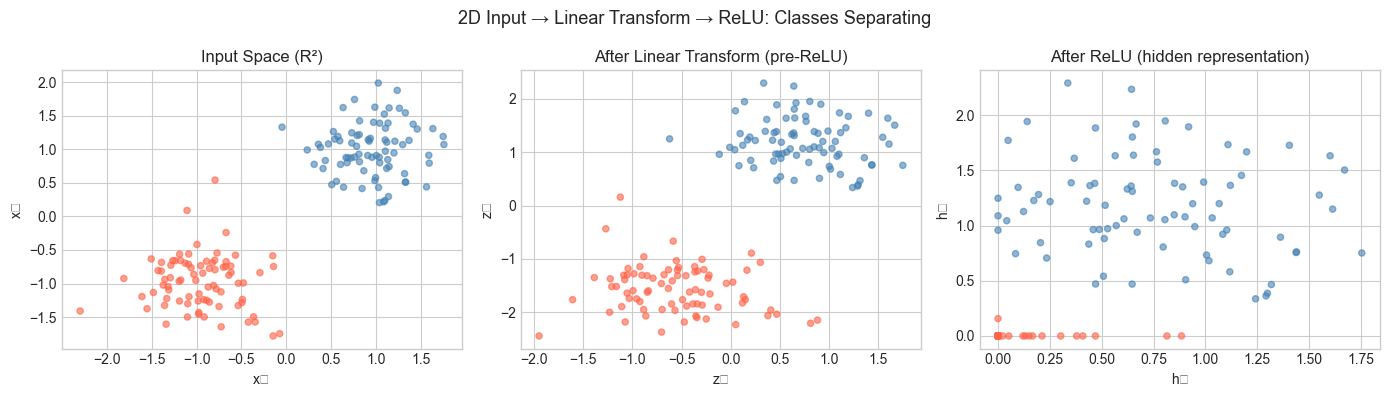

Input shape: (160, 2)
W1 shape: (3, 2)  — maps R^2 -> R^3
Z1 shape: (160, 3)  — after linear transform
H1 shape: (160, 3)  — after ReLU


In [1]:
# --- Visualization: How layers transform a 2D point cloud ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)

# Generate two classes of 2D points
N = 80
class0 = np.random.randn(N, 2) * 0.4 + np.array([1, 1])
class1 = np.random.randn(N, 2) * 0.4 + np.array([-1, -1])
X = np.vstack([class0, class1])          # (160, 2)
labels = np.array([0]*N + [1]*N)

# Layer 1: W1 (3x2), b1 (3,) — maps R^2 -> R^3
W1 = np.array([[1.2, -0.5],
               [0.3,  1.1],
               [-0.8, 0.6]])
b1 = np.array([0.1, -0.2, 0.3])

def relu(z):
    return np.maximum(0, z)

# Forward through layer 1
Z1 = X @ W1.T + b1     # (160, 3)
H1 = relu(Z1)          # (160, 3) — nonlinearity applied

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['steelblue' if l == 0 else 'tomato' for l in labels]

# Input space
axes[0].scatter(X[:, 0], X[:, 1], c=colors, alpha=0.6, s=20)
axes[0].set_title('Input Space (R²)', fontsize=12)
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')

# After linear transform (pre-activation)
axes[1].scatter(Z1[:, 0], Z1[:, 1], c=colors, alpha=0.6, s=20)
axes[1].set_title('After Linear Transform (pre-ReLU)', fontsize=12)
axes[1].set_xlabel('z₁'); axes[1].set_ylabel('z₂')

# After ReLU
axes[2].scatter(H1[:, 0], H1[:, 1], c=colors, alpha=0.6, s=20)
axes[2].set_title('After ReLU (hidden representation)', fontsize=12)
axes[2].set_xlabel('h₁'); axes[2].set_ylabel('h₂')

plt.suptitle('2D Input → Linear Transform → ReLU: Classes Separating', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Input shape: {X.shape}")
print(f"W1 shape: {W1.shape}  — maps R^2 -> R^3")
print(f"Z1 shape: {Z1.shape}  — after linear transform")
print(f"H1 shape: {H1.shape}  — after ReLU")

## 4. Mathematical Formulation

**Single layer (vector form):**
$$h^{(l)} = \sigma\left(W^{(l)} h^{(l-1)} + b^{(l)}\right)$$

Where:
- $h^{(l)} \in \mathbb{R}^{n_l}$ — output of layer $l$ (column vector)
- $W^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$ — weight matrix
- $b^{(l)} \in \mathbb{R}^{n_l}$ — bias vector
- $\sigma$ — elementwise nonlinearity (ReLU, sigmoid, tanh, etc.)
- $h^{(0)} = x$ — the input

**Batch form (processing multiple inputs simultaneously):**  
If $X \in \mathbb{R}^{B \times n_0}$ is a batch of $B$ inputs:
$$H^{(l)} = \sigma\left(H^{(l-1)} W^{(l)\top} + b^{(l)}\right)$$
where broadcasting handles the bias addition across all $B$ rows.

**Shape rule:** For a layer with $n_{in}$ inputs and $n_{out}$ outputs:
- $W$: shape `(n_out, n_in)`
- $b$: shape `(n_out,)`
- Input $x$: shape `(n_in,)` or batch `(B, n_in)`
- Output: shape `(n_out,)` or batch `(B, n_out)`

**Full network (L layers):**
$$f(x) = h^{(L)} = f_L \circ f_{L-1} \circ \cdots \circ f_1(x)$$

This is function composition *(introduced in ch054)* applied to matrix operations.

In [2]:
# Shape arithmetic demonstration
# Architecture: 4 inputs -> 8 hidden -> 4 hidden -> 2 outputs
architecture = [4, 8, 4, 2]

print("Layer-by-layer shape analysis:")
print(f"{'Layer':>8} {'W shape':>12} {'b shape':>10} {'Output shape':>14}")
print("-" * 50)
for i in range(len(architecture) - 1):
    n_in = architecture[i]
    n_out = architecture[i+1]
    print(f"Layer {i+1:>2}:  ({n_out:>3}, {n_in:>3})    ({n_out:>3},)       ({n_out:>3},)")

Layer-by-layer shape analysis:
   Layer      W shape    b shape   Output shape
--------------------------------------------------
Layer  1:  (  8,   4)    (  8,)       (  8,)
Layer  2:  (  4,   8)    (  4,)       (  4,)
Layer  3:  (  2,   4)    (  2,)       (  2,)


## 5. Python Implementation

In [3]:
# --- Implementation: Dense neural network forward pass from scratch ---
import numpy as np

def relu(z):
    """Rectified Linear Unit — elementwise."""
    return np.maximum(0, z)

def sigmoid(z):
    """Sigmoid activation — squashes to (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))

class DenseLayer:
    """
    A single fully-connected (dense) layer: output = activation(W @ x + b).

    Args:
        n_in:  number of input features
        n_out: number of output units
        activation: callable, applied elementwise after linear transform
    """
    def __init__(self, n_in, n_out, activation=relu):
        # He initialization: scales weights by sqrt(2/n_in)
        # — better for ReLU networks than plain random
        self.W = np.random.randn(n_out, n_in) * np.sqrt(2.0 / n_in)
        self.b = np.zeros(n_out)
        self.activation = activation

    def forward(self, x):
        """
        Forward pass through the layer.

        Args:
            x: input array, shape (n_in,) or (batch, n_in)

        Returns:
            h: activated output, shape (n_out,) or (batch, n_out)
        """
        z = x @ self.W.T + self.b   # linear: (batch, n_out)
        h = self.activation(z)       # nonlinear
        return h

class NeuralNetwork:
    """
    Feedforward neural network: a sequence of DenseLayers.

    Args:
        layer_sizes: list of ints, e.g. [2, 8, 4, 1]
    """
    def __init__(self, layer_sizes, output_activation=sigmoid):
        self.layers = []
        for i in range(len(layer_sizes) - 2):
            self.layers.append(DenseLayer(layer_sizes[i], layer_sizes[i+1], relu))
        # Final layer: different activation (often sigmoid for binary classification)
        self.layers.append(DenseLayer(layer_sizes[-2], layer_sizes[-1], output_activation))

    def forward(self, x):
        """
        Full forward pass: compose all layers.

        Args:
            x: input, shape (n_in,) or (batch, n_in)

        Returns:
            output of final layer
        """
        h = x
        for layer in self.layers:
            h = layer.forward(h)
        return h

# --- Test: forward pass shape check ---
np.random.seed(0)
net = NeuralNetwork([4, 8, 4, 1])

x_single = np.random.randn(4)       # single input
x_batch  = np.random.randn(16, 4)   # batch of 16

out_single = net.forward(x_single)
out_batch  = net.forward(x_batch)

print(f"Single input shape: {x_single.shape} -> output shape: {out_single.shape}")
print(f"Batch input shape:  {x_batch.shape} -> output shape: {out_batch.shape}")
print(f"Output range (sigmoid): [{out_batch.min():.3f}, {out_batch.max():.3f}]")

Single input shape: (4,) -> output shape: (1,)
Batch input shape:  (16, 4) -> output shape: (16, 1)
Output range (sigmoid): [0.500, 0.568]


## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_2856\1464872753.py:24: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_2856\1464872753.py:24: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


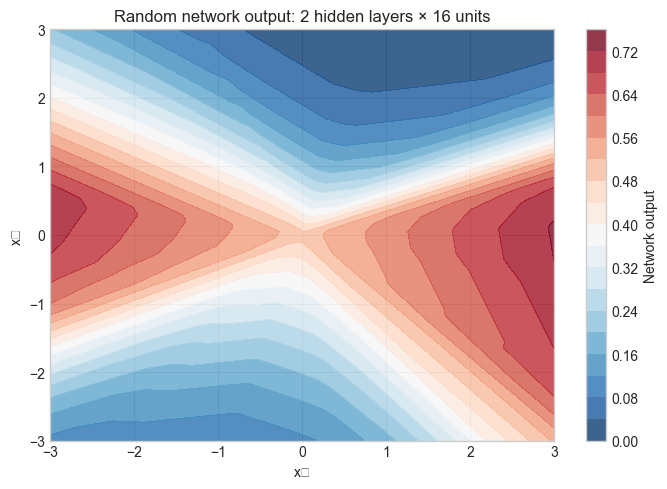

Architecture: [2, 16, 16, 1]
Total parameters: 337


In [4]:
# --- Experiment 1: Depth vs. expressiveness ---
# Hypothesis: deeper networks can represent more complex decision boundaries
# Try changing: N_HIDDEN_LAYERS between 1 and 5
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

N_HIDDEN_LAYERS = 2   # <-- modify this (try 1, 2, 3, 4)
HIDDEN_SIZE = 16      # <-- modify this (try 8, 32, 64)

architecture = [2] + [HIDDEN_SIZE] * N_HIDDEN_LAYERS + [1]
net = NeuralNetwork(architecture)

# Grid of inputs to visualize decision boundary
xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = net.forward(grid).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, preds, levels=20, cmap='RdBu_r', alpha=0.8)
plt.colorbar(label='Network output')
plt.title(f'Random network output: {N_HIDDEN_LAYERS} hidden layers × {HIDDEN_SIZE} units', fontsize=12)
plt.xlabel('x₁'); plt.ylabel('x₂')
plt.tight_layout(); plt.show()

total_params = sum(L.W.size + L.b.size for L in net.layers)
print(f"Architecture: {architecture}")
print(f"Total parameters: {total_params}")

C:\Users\user\AppData\Local\Temp\ipykernel_2856\1589546560.py:30: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
C:\Users\user\AppData\Local\Temp\ipykernel_2856\1589546560.py:30: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()


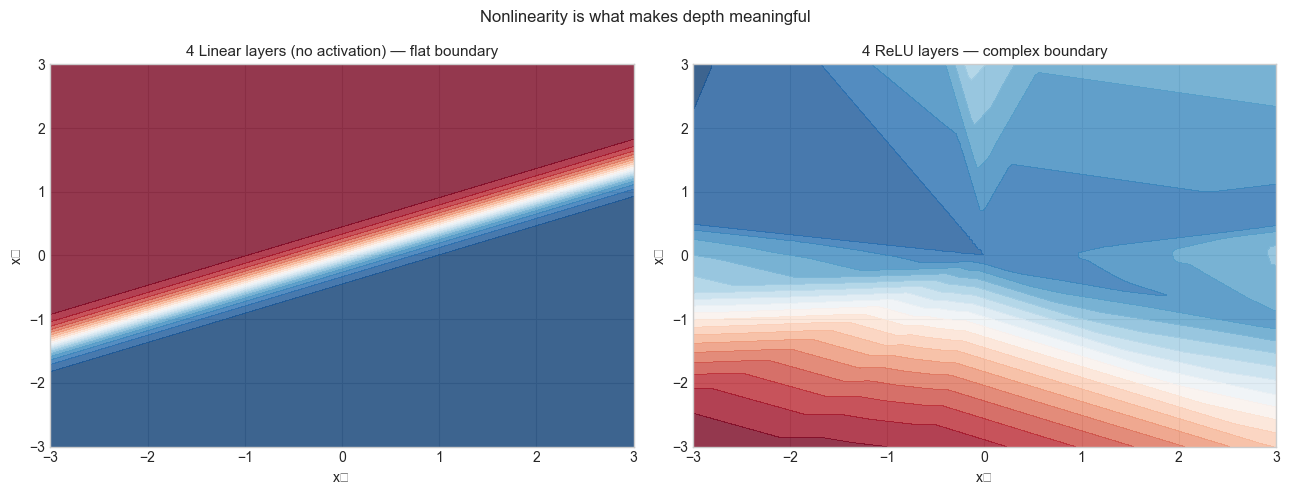

In [5]:
# --- Experiment 2: What happens without nonlinearity? ---
# Hypothesis: stacking linear layers without activation collapses to a single linear map
# Try changing: N_LAYERS to see that the boundary stays linear

def linear(z): return z   # identity activation = no nonlinearity

N_LAYERS = 4   # <-- modify this
architecture_linear = [2] + [8] * N_LAYERS + [1]
net_linear = NeuralNetwork(architecture_linear, output_activation=sigmoid)
# Override hidden layer activations to identity
for layer in net_linear.layers[:-1]:
    layer.activation = linear

preds_linear = net_linear.forward(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

net_relu = NeuralNetwork([2] + [8] * N_LAYERS + [1])
preds_relu = net_relu.forward(grid).reshape(xx.shape)

axes[0].contourf(xx, yy, preds_linear, levels=20, cmap='RdBu_r', alpha=0.8)
axes[0].set_title(f'{N_LAYERS} Linear layers (no activation) — flat boundary', fontsize=11)
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')

axes[1].contourf(xx, yy, preds_relu, levels=20, cmap='RdBu_r', alpha=0.8)
axes[1].set_title(f'{N_LAYERS} ReLU layers — complex boundary', fontsize=11)
axes[1].set_xlabel('x₁'); axes[1].set_ylabel('x₂')

plt.suptitle('Nonlinearity is what makes depth meaningful', fontsize=12)
plt.tight_layout(); plt.show()

## 7. Exercises

**Easy 1.** A network has architecture `[784, 256, 128, 10]`. How many parameters (weights + biases) does it have in total? Compute by hand, then verify with code.

**Easy 2.** Why does `x @ W.T + b` give the same result as `(W @ x.T).T + b` when `x` is a batch? Verify with a small numeric example.

**Medium 1.** Modify `DenseLayer` to store the pre-activation values `z` as `self.z` and the post-activation values as `self.h` during the forward pass. These are needed for backpropagation. Verify that shapes are correct for both single and batch inputs.

**Medium 2.** Implement a `tanh` activation and compare the output distribution of a 3-layer network using ReLU vs tanh on the same random input. Which activation produces outputs closer to zero-centered? Why does this matter for training? *(Hint: think about what zero-centered activations do to gradient magnitudes.)*

**Hard.** Prove that a composition of $L$ linear layers (no nonlinearity) is equivalent to a single linear layer. Specifically: if each layer computes $h^{(l)} = W^{(l)} h^{(l-1)}$, show that $h^{(L)} = W_{\text{eff}} x$ for some matrix $W_{\text{eff}}$. What is $W_{\text{eff}}$ in terms of the individual weight matrices? Verify numerically.

## 8. Mini Project

In [ ]:
# --- Mini Project: Visualize how a 2-layer network partitions R² ---
# Problem: Given a trained (or random-initialized) 2-layer network,
#   visualize what each hidden neuron has learned to detect.
# Task: Plot the activation of each hidden neuron over the input grid.
#   This shows that each neuron is a half-space detector (for ReLU).

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(7)
N_HIDDEN = 6   # <-- try 4, 8, 12

W1 = np.random.randn(N_HIDDEN, 2)
b1 = np.random.randn(N_HIDDEN)

# Input grid
xx, yy = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
grid = np.c_[xx.ravel(), yy.ravel()]  # (22500, 2)

# Hidden activations: each column = one neuron's response
Z1 = grid @ W1.T + b1          # (22500, N_HIDDEN)
H1 = np.maximum(0, Z1)         # ReLU

# Plot each hidden neuron's activation
n_cols = 3
n_rows = int(np.ceil(N_HIDDEN / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes = axes.ravel()

for i in range(N_HIDDEN):
    act = H1[:, i].reshape(xx.shape)
    axes[i].contourf(xx, yy, act, levels=20, cmap='viridis')
    axes[i].set_title(f'Hidden neuron {i+1}', fontsize=10)
    axes[i].set_xlabel('x₁'); axes[i].set_ylabel('x₂')

for j in range(N_HIDDEN, len(axes)):
    axes[j].axis('off')

plt.suptitle('Each ReLU neuron activates on a half-space in R²', fontsize=13)
plt.tight_layout()
plt.show()

print("Each neuron computes: ReLU(w·x + b)")
print("The boundary between 0 and nonzero is the hyperplane w·x + b = 0")
print("A network combines these half-space detectors to carve out regions.")

## 9. Chapter Summary & Connections

- A neural network forward pass is a composition of affine transformations (`W @ x + b`) interleaved with elementwise nonlinearities.
- The weight matrix `W` is the linear transformation *(ch164)*; it rotates, scales, and projects the input space.
- Without nonlinear activations, any depth of linear layers collapses to a single matrix multiplication — depth buys nothing.
- Shape arithmetic (`n_out × n_in`) governs every layer; getting shapes right is prerequisite to everything else.
- Batch processing vectorizes over multiple inputs simultaneously using matrix multiplication, exploiting hardware parallelism.

**Backward connections:**
- This chapter applies ch154 (matrix multiplication), ch164 (linear transformations), and ch176 (matrix calculus) directly.

**Forward connections:**
- ch178 — Linear Layers in Deep Learning: extends this to batched gradient computation and the full training loop.
- ch216 — Backpropagation Intuition: the chain rule from ch176 will be applied to this exact forward pass to derive parameter gradients.
- ch228 — Gradient-Based Learning: uses the network defined here as the model being optimized.

**Going deeper:** *Deep Learning* by Goodfellow, Bengio & Courville, Chapter 6 — covers the universal approximation theorem, which formalizes why depth + nonlinearity is sufficient to represent any continuous function.